<a href="https://colab.research.google.com/github/andresalmanzal/tfm-siniestros-bogota/blob/main/notebooks/01_eda_y_validacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TFM  Predicción de gravedad y mapa de riesgo de siniestros viales en Bogotá
**Autor:** Ovidio Almanza Ledesma · **Máster en Data Science, Big Data & Business Analytics (UCM)**

## Notebook 01  Análisis exploratorio (EDA) y diseño de validación

### Problema de negocio
Las autoridades de movilidad de Bogotá operan con presupuesto limitado para seguridad vial (marco *Visión Cero*). La pregunta de negocio es:
> **¿Dónde, cuándo y bajo qué condiciones es más probable que ocurra un siniestro vial *grave*, para priorizar intervenciones?**

### Enfoque (decidido)
Solución **híbrida** en dos piezas que se alimentan entre sí:
1. **Modelo supervisado** de clasificación de la **gravedad** del siniestro (`GRAVEDAD`), con interpretabilidad (SHAP) para responder *"¿qué hace que un siniestro sea grave?"*.
2. **Productivización**: un **mapa de riesgo** que combina densidad observada y gravedad esperada predicha, agregada por zona, mes y día de la semana.

### Alcance de ESTE notebook
Cargar la fuente de forma reproducible, sanearla con criterio, explorarla (target, clase, tiempo, espacio, calidad de datos) y **dejar fijada y justificada la métrica y la estrategia de validación antes de modelar**. Produce un artefacto limpio (`.parquet`) que alimenta al notebook 02.

### Fuente y licencia
- **Conjunto:** *Histórico Siniestros Bogotá D.C.* - Secretaría Distrital de Movilidad (SDM), publicado en Datos Abiertos Bogotá.
- **Grano:** un registro por siniestro georreferenciado (capa de puntos), 2015–2021, actualización trimestral.
- **Licencia:** Creative Commons Attribution 4.0 (CC BY 4.0) - uso libre con atribución.
- **Acceso:** API Esri REST (paginada) o descarga directa CSV/GeoJSON. Origen: SIGAT, alimentado por el IPAT (Informe Policial de Accidentes de Tránsito).

**Nota metodológica (proceso → memoria):** esta capa de puntos trae gravedad, clase, localidad, fecha y coordenadas, pero **no** las variables que más discriminan la gravedad (tipo de actor vial, tipo de vehículo, hipótesis/causa), que viven en las tablas relacionales del conjunto *Siniestros Viales Consolidados*. Eso motiva el **notebook 02 (enriquecimiento)**.

> **Hallazgos (carga):** la API Esri REST recuperó **209.861 siniestros** georreferenciados (19 columnas con geometría), cacheados en `data/raw/`. El volumen (~210 mil registros, periodo 2015–2021) confirma un dataset de tamaño relevante, y la carga quedó 100 % reproducible sin intervención manual.

In [3]:
# Configuración e imports
import os, io, time, unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

for d in ["data/raw", "data/processed", "notebooks", "app"]:
    Path(d).mkdir(parents=True, exist_ok=True)

print("Entorno listo. pandas", pd.__version__)

Entorno listo. pandas 2.2.2


### Carga reproducible
**Técnico:** el profesor podrá ejecutar sin configuración previa. La función intenta, en orden: (1) caché local, (2) API Esri REST paginada - la vía más estable, sin nombres de archivo frágiles-, (3) descarga directa de CSV, (4) subida manual si estamos en Colab, o (5) error explícito en local. Cachea para no volver a descargar.

**Negocio:** garantizamos un análisis *reproducible y auditable* de extremo a extremo; cualquiera puede regenerar los resultados desde cero.

In [4]:
# Fuentes
ARCGIS_URL = ("https://services2.arcgis.com/NEwhEo9GGSHXcRXV/arcgis/rest/"
              "services/HistoricoSiniestros/FeatureServer/0/query")
CSV_URL = ("https://datosabiertos.bogota.gov.co/dataset/"
           "8624f916-1db2-4c17-b669-19a19b35d1ca/resource/"
           "f5862aaa-4e1c-463e-94d5-f04db8164360/download/"
           "historico_siniestros_bogota_d.c_-.csv")

DATA_RAW = Path("data/raw")
CACHE = DATA_RAW / "historico_siniestros.parquet"

def _descargar_arcgis(url=ARCGIS_URL, page=2000, timeout=60, max_paginas=2000):
    """Descarga paginada vía Esri REST. Atributos + geometría (en WGS84)."""
    registros, offset = [], 0
    for _ in range(max_paginas):
        params = {
            "where": "1=1", "outFields": "*", "returnGeometry": "true",
            "outSR": 4326, "f": "json",
            "resultOffset": offset, "resultRecordCount": page,
            "orderByFields": "OBJECTID",
        }
        r = requests.get(url, params=params, timeout=timeout)
        r.raise_for_status()
        data = r.json()
        feats = data.get("features", [])
        if not feats:
            break
        for ft in feats:
            attr = dict(ft.get("attributes", {}))
            geom = ft.get("geometry") or {}
            attr["GEOM_LON"], attr["GEOM_LAT"] = geom.get("x"), geom.get("y")
            registros.append(attr)
        offset += len(feats)
        if len(feats) < page and not data.get("exceededTransferLimit", False):
            break
    if not registros:
        raise RuntimeError("ArcGIS no devolvió registros.")
    return pd.DataFrame(registros)

def _descargar_csv(url=CSV_URL, timeout=180):
    r = requests.get(url, timeout=timeout)
    r.raise_for_status()
    return pd.read_csv(io.BytesIO(r.content), low_memory=False)

def cargar_siniestros(forzar=False):
    if CACHE.exists() and not forzar:
        print(f"[cache] {CACHE}")
        return pd.read_parquet(CACHE)

    df = None
    for nombre, fn in [("ArcGIS REST (paginado)", _descargar_arcgis),
                       ("CSV directo", _descargar_csv)]:
        try:
            print(f"[descarga] {nombre} ...")
            df = fn()
            break
        except Exception as e:
            print(f"   falló: {e}")

    if df is None:
        try:
            from google.colab import files  # type: ignore
            print("Sube el CSV de 'Histórico Siniestros':")
            up = files.upload()
            df = pd.read_csv(io.BytesIO(up[next(iter(up))]), low_memory=False)
        except ImportError:
            raise RuntimeError(
                "Sin conexión a la fuente y fuera de Colab. Descarga el CSV de "
                "datosabiertos.bogota.gov.co y colócalo en data/raw/."
            )

    try:
        df.to_parquet(CACHE, index=False)
        print(f"[cache guardado] {CACHE}")
    except Exception:
        df.to_csv(CACHE.with_suffix(".csv"), index=False)
        print("[cache guardado] CSV (pyarrow no disponible)")

    print(f"Filas: {len(df):,} | Columnas: {df.shape[1]}")
    return df

In [5]:
df_raw = cargar_siniestros()
df_raw.head()

[descarga] ArcGIS REST (paginado) ...
[cache guardado] data/raw/historico_siniestros.parquet
Filas: 209,861 | Columnas: 19


,OBJECTID,FORMULARIO,CODIGO_ACCIDENTE,FECHA_OCURRENCIA_ACC,ANO_OCURRENCIA_ACC,DIRECCION,GRAVEDAD,CLASE_ACC,LOCALIDAD,FECHA_HORA_ACC,LATITUD,LONGITUD,CIV,PK_CALZADA,FECHA,HORA,FECHA_HORA,GEOM_LON,GEOM_LAT
0,631773,A000405746,4453111,1470096000000,2016,KR 10-CL 11 S 02,SOLO DANOS,CHOQUE,SAN CRISTOBAL,1470096000000,4.582107,-74.089798,4000156,241544,2/08/2016,2/08/2016,None,-74.089798,4.582107
1,631774,A000759671,4509563,1519344000000,2018,AV AVENIDA DE LAS AMERICAS-KR 68 2,SOLO DANOS,CHOQUE,PUENTE ARANDA,1519344000000,4.628828,-74.122387,16004636,169764,23/02/2018,23/02/2018,None,-74.122387,4.628828
2,631775,A000475012,4461204,1476748800000,2016,DG 38A-KR 31 S 02,SOLO DANOS,CHOQUE,RAFAEL URIBE URIBE,1476748800000,4.587274,-74.122714,18000257,239648,18/10/2016,18/10/2016,None,-74.122714,4.587274
3,631776,A000608458,4483742,1496620800000,2017,KR 15-CL 6 S 02,CON HERIDOS,CHOQUE,ANTONIO NARINO,1496620800000,4.589216,-74.094099,15000741,240101,None,None,None,-74.094099,4.589216
4,631777,A000759748,4509882,1519689600000,2018,CL 145-KR 90 2,SOLO DANOS,CHOQUE,SUBA,1519689600000,4.737704,-74.084170,11005610,9705,None,None,None,-74.084170,4.737704


### Control de calidad temporal (antes de derivar variables)
Antes de construir features temporales verifico si el dataset contiene la **hora del día** del siniestro. Es un control barato que evita levantar un análisis sobre un campo inexistente.

> **Hallazgo crítico:** **no hay hora del día.** Tanto `FECHA_OCURRENCIA_ACC` como `FECHA_HORA_ACC` están al **100 % a las 00:00** (solo fecha, almacenada a medianoche); la columna de texto `HORA` está **vacía en el 99,99 %** de los registros (los 3 valores no nulos contienen *fechas*, no horas) y `FECHA_HORA` está completamente vacía. **Decisión:** descarto la dimensión horaria y trabajo con granularidad de **año, mes y día de la semana**. Esto ajusta la productivización: el mapa de riesgo se segmenta por zona, mes y día de la semana (no por franja horaria).

In [6]:
# Diagnóstico de calidad temporal: ¿existe hora del día?
for c in ["FECHA_OCURRENCIA_ACC", "FECHA_HORA_ACC"]:
    h = pd.to_datetime(pd.to_numeric(df_raw[c], errors="coerce"), unit="ms", errors="coerce").dt.hour
    print(f"{c} -> % a las 00:00 = {(h == 0).mean()*100:.1f} | horas únicas: {sorted(h.dropna().unique())}")

print("\nHORA (texto): % no nulos =", round(df_raw['HORA'].notna().mean()*100, 4))
print("FECHA_HORA:   % no nulos =", round(df_raw['FECHA_HORA'].notna().mean()*100, 4))
print("Muestra HORA no nula:", list(df_raw['HORA'].dropna().unique()[:5]))

FECHA_OCURRENCIA_ACC -> % a las 00:00 = 100.0 | horas únicas: [np.int32(0)]
FECHA_HORA_ACC -> % a las 00:00 = 100.0 | horas únicas: [np.int32(0)]

HORA (texto): % no nulos = 0.0014
FECHA_HORA:   % no nulos = 0.0
Muestra HORA no nula: ['2/08/2016', '23/02/2018', '18/10/2016']


### Primer vistazo
Dimensiones, tipos, duplicados y peso en memoria. No asumo los dtypes: los inspecciono y luego lo fuerzo.

> **Hallazgos (estructura):** **209.861 filas × 19 columnas**, **0 duplicados** exactos, ~96 MB en memoria. Periodo **2015–2021**. Cardinalidades: gravedad con **3 niveles**, clase con **7**, localidad con **21** categorías. Las columnas `FECHA`, `HORA` y `FECHA_HORA` están esencialmente **vacías** (≤3 valores no nulos) y se descartan. `CIV` y `PK_CALZADA` usan **0 como marcador de "no asignado"**, no como valor real (a tener en cuenta si se usan como features).

In [7]:
print("Dimensiones:", df_raw.shape)
print("\nTipos de dato:")
print(df_raw.dtypes)
print("\nDuplicados exactos:", df_raw.duplicated().sum())
print(f"Memoria: {df_raw.memory_usage(deep=True).sum()/1e6:,.1f} MB")
df_raw.describe(include="all").T

Dimensiones: (209861, 19)

Tipos de dato:
OBJECTID                  int64
FORMULARIO               object
CODIGO_ACCIDENTE          int64
FECHA_OCURRENCIA_ACC      int64
ANO_OCURRENCIA_ACC        int64
DIRECCION                object
GRAVEDAD                 object
CLASE_ACC                object
LOCALIDAD                object
FECHA_HORA_ACC            int64
LATITUD                 float64
LONGITUD                float64
CIV                       int64
PK_CALZADA                int64
FECHA                    object
HORA                     object
FECHA_HORA               object
GEOM_LON                float64
GEOM_LAT                float64
dtype: object

Duplicados exactos: 0
Memoria: 96.3 MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
OBJECTID,209861.0,NaN,NaN,NaN,736703.0,60581.796759,631773.0,684238.0,736703.0,789168.0,841633.0
FORMULARIO,209861,209861,A001304781,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CODIGO_ACCIDENTE,209861.0,NaN,NaN,NaN,7530927.837859,3022279.587633,4401420.0,4461035.0,10448517.0,10506218.0,10561067.0
FECHA_OCURRENCIA_ACC,209861.0,NaN,NaN,NaN,1528635709632.566406,62160836633.473976,1420070400000.0,1476489600000.0,1526688000000.0,1576540800000.0,1640908800000.0
ANO_OCURRENCIA_ACC,209861.0,NaN,NaN,NaN,2017.925527,1.942722,2015.0,2016.0,2018.0,2019.0,2021.0
DIRECCION,209861,106403,KR 80-CL 2 51,213,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GRAVEDAD,209861,3,SOLO DANOS,134812,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CLASE_ACC,209861,7,CHOQUE,180154,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LOCALIDAD,209861,21,KENNEDY,25116,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FECHA_HORA_ACC,209861.0,NaN,NaN,NaN,1528635709632.566406,62160836633.473976,1420070400000.0,1476489600000.0,1526688000000.0,1576540800000.0,1640908800000.0


### Saneamiento defensivo de tipos y texto
**Técnico:** coerción numérica explícita (`pd.to_numeric(errors="coerce")`) en coordenadas/año; normalización de texto con `unicodedata` (mayúsculas, sin acentos, sin espacios sobrantes) para conciliar categorías entre cargas; **mapeo explícito (no fuzzy)** de la gravedad a etiquetas legibles; parser de fechas robusto a *epoch en milisegundos*. Creo un `es_grave` (1 = "Con muertos"), la clase crítica de negocio.

**Negocio:** Estandarizo para que las cifras sean consistentes y no se inflen/dividan por tildes o mayúsculas, y marco explícitamente el caso más costoso (siniestro fatal).

> **Hallazgos (saneo):** el mapeo de gravedad cubrió las **3 categorías sin dejar valores sin mapear**. Confirmado el descarte de la hora; las derivadas temporales fiables son `anio`, `mes` y `dia_semana`.

In [8]:
#  Funciones de saneamiento (probadas)
def normalizar_texto(serie: pd.Series) -> pd.Series:
    def _norm(x):
        if pd.isna(x):
            return np.nan
        s = unicodedata.normalize("NFKD", str(x).strip().upper())
        s = "".join(c for c in s if not unicodedata.combining(c))
        s = " ".join(s.split())
        return s if s else np.nan
    return serie.map(_norm)

def coerce_num(serie: pd.Series) -> pd.Series:
    return pd.to_numeric(serie, errors="coerce")

def parse_fecha(serie: pd.Series) -> pd.Series:
    s = pd.to_numeric(serie, errors="coerce")
    if s.notna().mean() > 0.5 and s.dropna().abs().median() > 1e10:  # epoch ms
        return pd.to_datetime(s, unit="ms", errors="coerce")
    return pd.to_datetime(serie, errors="coerce")

df = df_raw.copy()

# Categóricas normalizadas
for col in ["GRAVEDAD", "CLASE_ACC", "LOCALIDAD"]:
    if col in df:
        df[col + "_norm"] = normalizar_texto(df[col])

# Mapeo explícito de gravedad -> etiqueta legible (auditable)
MAP_GRAVEDAD = {
    "SOLO DANOS": "Solo daños",
    "CON HERIDOS": "Con heridos",
    "CON MUERTOS": "Con muertos",
}
df["gravedad"] = df["GRAVEDAD_norm"].map(MAP_GRAVEDAD)
no_mapeados = sorted(set(df["GRAVEDAD_norm"].dropna()) - set(MAP_GRAVEDAD))
print("Categorías de gravedad sin mapear:", no_mapeados if no_mapeados else "ninguna (OK)")

# Variable binaria de letalidad (clase crítica de negocio)
df["es_grave"] = (df["gravedad"] == "Con muertos").astype("Int64")

# Coordenadas: columnas oficiales con respaldo de la geometría
df["lat"] = coerce_num(df.get("LATITUD")).fillna(coerce_num(df.get("GEOM_LAT")))
df["lon"] = coerce_num(df.get("LONGITUD")).fillna(coerce_num(df.get("GEOM_LON")))

# Fechas y derivadas temporales (SIN hora: ver diagnóstico)
df["fecha_hora"] = parse_fecha(df.get("FECHA_HORA_ACC"))
df["anio"] = coerce_num(df.get("ANO_OCURRENCIA_ACC")).fillna(df["fecha_hora"].dt.year).astype("Int64")
df["mes"] = df["fecha_hora"].dt.month
df["dia_semana"] = df["fecha_hora"].dt.dayofweek   # 0=lunes

print("\nTipos saneados:")
print(df[["gravedad", "es_grave", "lat", "lon", "fecha_hora", "anio", "mes", "dia_semana"]].dtypes)
df[["GRAVEDAD", "gravedad", "es_grave", "lat", "lon", "fecha_hora"]].head()

Categorías de gravedad sin mapear: ninguna (OK)

Tipos saneados:
gravedad              object
es_grave               Int64
lat                  float64
lon                  float64
fecha_hora    datetime64[ns]
anio                   Int64
mes                    int32
dia_semana             int32
dtype: object


,GRAVEDAD,gravedad,es_grave,lat,lon,fecha_hora
0,SOLO DANOS,Solo daños,0,4.582107,-74.089798,2016-08-02
1,SOLO DANOS,Solo daños,0,4.628828,-74.122387,2018-02-23
2,SOLO DANOS,Solo daños,0,4.587274,-74.122714,2016-10-18
3,CON HERIDOS,Con heridos,0,4.589216,-74.094099,2017-06-05
4,SOLO DANOS,Solo daños,0,4.737704,-74.084170,2018-02-27


### EDA · El target: gravedad y su desbalance
La distribución de la gravedad determina la métrica.

> **Hallazgos (target):** fuerte desbalance — **Solo daños 64,24 %** (134.812), **Con heridos 34,14 %** (71.656) y **Con muertos 1,62 %** (3.393). La clase fatal es ~1 de cada 62 siniestros. Esto **descarta la exactitud** como métrica principal y justifica priorizar el *recall* de la clase fatal y el F1 macro (ver sección de métrica).

             conteo      %
gravedad                  
Solo daños   134812  64.24
Con heridos   71656  34.14
Con muertos    3393   1.62


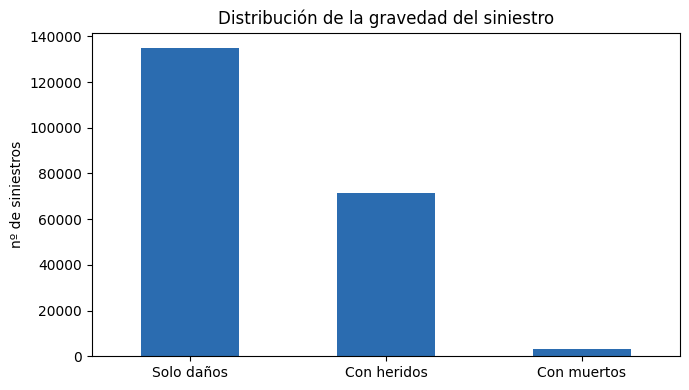

In [9]:
g = df["gravedad"].value_counts(dropna=False)
g_pct = (df["gravedad"].value_counts(normalize=True, dropna=False) * 100).round(2)
print(pd.concat([g.rename("conteo"), g_pct.rename("%")], axis=1))

ax = g.plot(kind="bar", color="#2b6cb0", figsize=(7, 4))
ax.set_title("Distribución de la gravedad del siniestro")
ax.set_xlabel(""); ax.set_ylabel("nº de siniestros")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

### EDA · Clase de siniestro vs. gravedad
> **Hallazgos (clase):** el **choque** domina el volumen (180.154; ~86 %) pero es mayoritariamente *solo daños* (74,5 %) con baja letalidad (0,9 % fatal). La letalidad se concentra en **volcamiento (9,7 % fatal)** y **atropello (7,2 % fatal, 92,5 % con heridos)**. Lectura de negocio: *el tipo de siniestro más frecuente no es el más mortal*; peatones (atropello) y volcamientos son donde se juegan las vidas. `CLASE_ACC` es una señal predictiva fuerte y será clave en la interpretabilidad.

In [10]:
print(df["CLASE_ACC_norm"].value_counts(dropna=False), "\n")

ct = pd.crosstab(df["CLASE_ACC_norm"], df["gravedad"], normalize="index").round(3) * 100
ct = ct.reindex(df["CLASE_ACC_norm"].value_counts().index)
print("Composición de gravedad por clase (% por fila):")
ct

CLASE_ACC_norm
CHOQUE               180154
ATROPELLO             21029
CAIDA DE OCUPANTE      4872
VOLCAMIENTO            2901
OTRO                    871
INCENDIO                 24
AUTOLESION               10
Name: count, dtype: int64 

Composición de gravedad por clase (% por fila):


gravedad,Con heridos,Con muertos,Solo daños
CLASE_ACC_norm,,,
CHOQUE,24.7,0.9,74.5
ATROPELLO,92.5,7.2,0.2
CAIDA DE OCUPANTE,98.8,0.8,0.4
VOLCAMIENTO,74.5,9.7,15.8
OTRO,84.4,0.8,14.8
INCENDIO,12.5,0.0,87.5
AUTOLESION,100.0,0.0,0.0


### EDA · Patrones temporales
> **Hallazgos (tiempo):** tendencia creciente 2015→2018-2019 (pico aprox. 33,5 mil/año), **caída abrupta en 2020 (−32 %) por la pandemia** y recuperación parcial en 2021. Estacionalidad mensual leve. Por volumen, el **viernes** es el día más siniestrado y el **domingo** el de menos. Pero al mirar la **letalidad** aparece el patrón más relevante: **el domingo es, con diferencia, el día más mortal (~2,3 % de siniestros fatales, frente a ~1,5 % entre semana)**, seguido del sábado (~1,65 %). Es el clásico *efecto fin de semana*: menos siniestros pero más letales. Refuerza la lógica del mapa de riesgo —ponderar por **gravedad**, no solo por volumen— y convierte a `dia_semana` en una variable útil para el modelo.

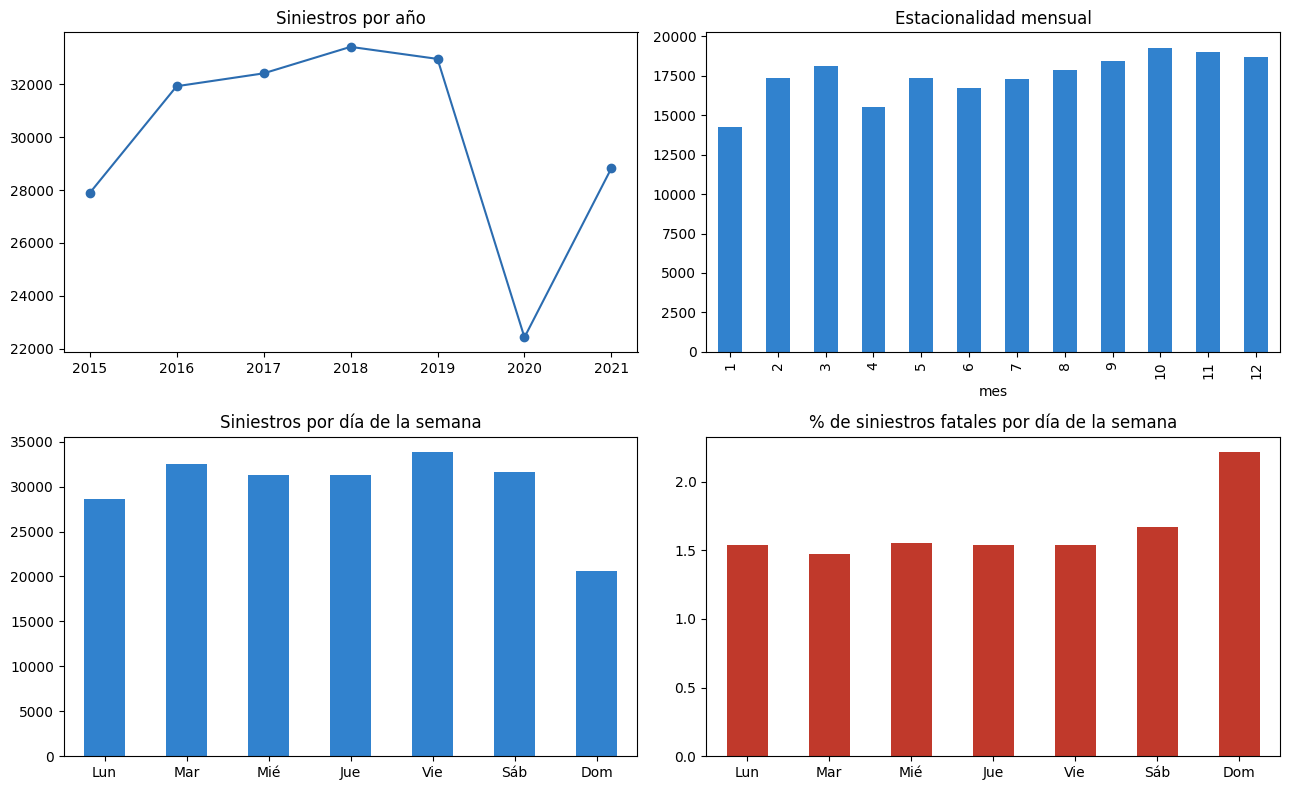

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

df.groupby("anio").size().plot(ax=axes[0, 0], marker="o", color="#2b6cb0")
axes[0, 0].set_title("Siniestros por año"); axes[0, 0].set_xlabel("")

df.groupby("mes").size().plot(kind="bar", ax=axes[0, 1], color="#3182ce")
axes[0, 1].set_title("Estacionalidad mensual"); axes[0, 1].set_xlabel("mes")

dias = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]
df.groupby("dia_semana").size().reindex(range(7)).plot(kind="bar", ax=axes[1, 0], color="#3182ce")
axes[1, 0].set_xticklabels(dias, rotation=0)
axes[1, 0].set_title("Siniestros por día de la semana"); axes[1, 0].set_xlabel("")

# Panel 'hora' (no disponible) -> letalidad por día de la semana
(df.groupby("dia_semana")["es_grave"].mean().mul(100).reindex(range(7))
   .plot(kind="bar", ax=axes[1, 1], color="#c0392b"))
axes[1, 1].set_xticklabels(dias, rotation=0)
axes[1, 1].set_title("% de siniestros fatales por día de la semana"); axes[1, 1].set_xlabel("")

plt.tight_layout(); plt.show()

### EDA · Patrones espaciales
> **Hallazgos (espacio):** **100 % de coordenadas válidas** dentro de Bogotá (sin (0,0) ni puntos fuera; nada que limpiar aquí). Hallazgo clave para la priorización: **volumen y letalidad no coinciden**. Kennedy lidera en número de siniestros (25.116) con letalidad media (1,89 %), mientras que las localidades **más letales** son **Ciudad Bolívar (3,03 %)**, **San Cristóbal (2,47 %)**, **Rafael Uribe Uribe (2,41 %)** y **Bosa (2,13 %)** — periferia de menores ingresos. Esto sostiene un mapa de riesgo orientado a *dónde los siniestros son más mortales*, no solo a dónde son más frecuentes.

Coordenadas dentro de bbox Bogotá: 100.00% | fuera/nulas: 0

Top localidades por nº de siniestros:
                    siniestros  tasa_fatal_pct
LOCALIDAD_norm                                
KENNEDY                  25116            1.89
ENGATIVA                 22085            1.40
USAQUEN                  20109            0.86
SUBA                     20021            1.39
FONTIBON                 17279            1.42
PUENTE ARANDA            14957            1.61
CHAPINERO                12153            0.80
TEUSAQUILLO              10657            1.10
BARRIOS UNIDOS           10593            1.03
BOSA                      9922            2.13
CIUDAD BOLIVAR            8450            3.03
LOS MARTIRES              6606            1.74
RAFAEL URIBE URIBE        5736            2.41
SANTA FE                  5714            1.79
SAN CRISTOBAL             5669            2.47


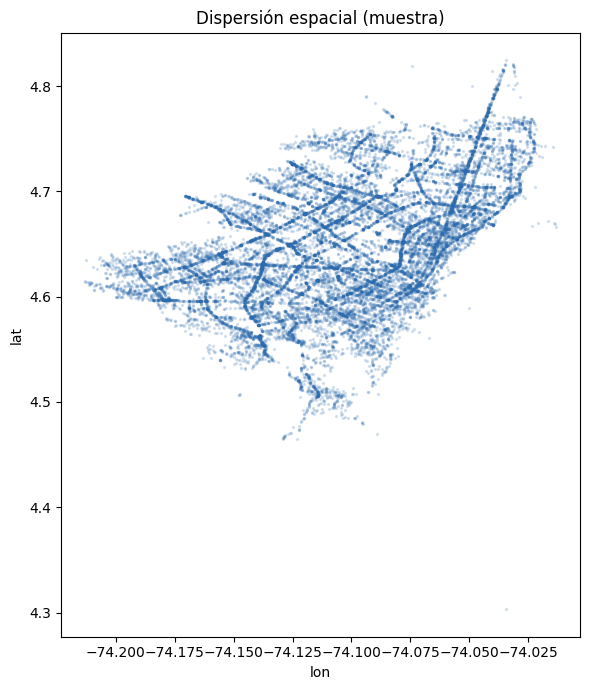

In [12]:
def en_bbox_bogota(lat, lon):
    return lat.between(4.0, 4.9) & lon.between(-74.30, -73.95)

df["coord_valida"] = en_bbox_bogota(df["lat"], df["lon"])
print("Coordenadas dentro de bbox Bogotá:",
      f"{df['coord_valida'].mean()*100:.2f}%",
      f"| fuera/nulas: {(~df['coord_valida']).sum():,}")

loc = (df.groupby("LOCALIDAD_norm")
         .agg(siniestros=("OBJECTID", "size"),
              tasa_fatal_pct=("es_grave", lambda s: round(s.mean()*100, 2)))
         .sort_values("siniestros", ascending=False))
print("\nTop localidades por nº de siniestros:")
print(loc.head(15))

m = df[df["coord_valida"]].sample(min(20000, int(df["coord_valida"].sum())), random_state=SEED)
plt.figure(figsize=(6, 7))
plt.scatter(m["lon"], m["lat"], s=2, alpha=0.15, color="#2b6cb0")
plt.title("Dispersión espacial (muestra)"); plt.xlabel("lon"); plt.ylabel("lat")
plt.tight_layout(); plt.show()

### Calidad de datos: missings y atípicos (con criterio, sin borrar por defecto)
**Técnico:** medimos el *missingness* y revisamos si es informativo antes de eliminar nada.

**Negocio:** un dato faltante a veces *es* información; borrarlo a ciegas sesga el diagnóstico y, con él, dónde se invierte el presupuesto.

> **Hallazgos (calidad):** el dataset es **notablemente completo** a nivel de fila: 0 % de nulos en gravedad, clase, coordenadas y fecha; solo **46 localidades nulas (0,02 %)**. No hay *missingness informativo* en coordenadas (0 % en las tres clases de gravedad). Los problemas relevantes no son nulos aleatorios sino **estructurales**: la ausencia de hora y las columnas `FECHA`/`HORA`/`FECHA_HORA` vacías, ya tratadas. No se elimina ninguna fila.

In [13]:
def reporte_missing(df, cols=None):
    d = df[cols] if cols else df
    n = len(d)
    return (d.isna().sum().to_frame("n_missing")
             .assign(pct=lambda x: (x["n_missing"]/n*100).round(2))
             .sort_values("pct", ascending=False))

cols_clave = ["gravedad", "CLASE_ACC_norm", "LOCALIDAD_norm", "lat", "lon", "fecha_hora"]
print("Missingness en columnas clave:")
print(reporte_missing(df, cols_clave), "\n")

falta_coord = df["lat"].isna() | df["lon"].isna() | (~df["coord_valida"])
print("Tasa de coordenada faltante/inválida por gravedad (%):")
print((df.assign(falta=falta_coord).groupby("gravedad")["falta"].mean()*100).round(2))

Missingness en columnas clave:
                n_missing   pct
LOCALIDAD_norm         46  0.02
gravedad                0  0.00
CLASE_ACC_norm          0  0.00
lat                     0  0.00
lon                     0  0.00
fecha_hora              0  0.00 

Tasa de coordenada faltante/inválida por gravedad (%):
gravedad
Con heridos    0.0
Con muertos    0.0
Solo daños     0.0
Name: falta, dtype: float64


### Métrica y estrategia de validación (fijadas y justificadas ANTES de modelar)

**Métrica.**
- *Técnico:* con la clase fatal en solo **1,62 %**, la **exactitud queda descartada** (un modelo que nunca prediga "Con muertos" tendría ~98 % de acierto e ignoraría justo lo crítico). Usamos: **F1 macro** como métrica de selección; **recall de "Con muertos"** como métrica de negocio prioritaria; **PR-AUC** por clase (más informativa que ROC-AUC bajo fuerte desbalance); y reportamos **matriz de confusión** y métricas por clase.
- *Negocio:* "No sirve acertar mucho en promedio si fallamos justo en los siniestros que matan. Medimos sobre todo qué tan bien atrapamos los casos graves."

**Validación.**
- *Técnico:* partición **temporal**, no aleatoria (en producción se predice el futuro desde el pasado; un k-fold aleatorio filtraría información y autocorrelación espacio-temporal). Todo ajuste se aprende **solo** en *train*. Tratamos **2020 como año atípico** (COVID) y validamos en años representativos del despliegue.
- *Negocio:* "Probamos el modelo prediciendo años que nunca vio, como hará al operar; así la cifra de calidad es honesta."

> La métrica del **mapa de riesgo** (calibración espacial: riesgo predicho vs. incidencia observada por zona) se detalla en el notebook de modelado/interpretabilidad.

In [14]:
def particion_temporal(df, col_anio="anio", anios_test=None, excluir=(2020,)):
    """Train = años antiguos; Test = años recientes. 2020 excluido por COVID."""
    anios = sorted(int(a) for a in df[col_anio].dropna().unique() if int(a) not in excluir)
    if anios_test is None:
        anios_test = anios[-1:]
    anios_val = [a for a in anios if a not in anios_test][-1:]
    anios_train = [a for a in anios if a not in anios_test + anios_val]
    return {"train": anios_train, "val": anios_val, "test": anios_test, "excluidos": list(excluir)}

part = particion_temporal(df)
print("Partición temporal propuesta:", part)
for nombre, anios in [("train", part["train"]), ("val", part["val"]), ("test", part["test"])]:
    sub = df[df["anio"].isin(anios)]
    print(f"  {nombre:5s} {anios}: {len(sub):,} filas | % fatal: {sub['es_grave'].mean()*100:.2f}")

Partición temporal propuesta: {'train': [2015, 2016, 2017, 2018], 'val': [2019], 'test': [2021], 'excluidos': [2020]}
  train [2015, 2016, 2017, 2018]: 125,646 filas | % fatal: 1.65
  val   [2019]: 32,962 filas | % fatal: 1.50
  test  [2021]: 28,829 filas | % fatal: 1.59


> **Hallazgos (validación):** la partición queda en **train 2015–2018 (125.646 filas)**, **validación 2019 (32.962)** y **test 2021 (28.829)**, con **2020 excluido** por el choque COVID. La prevalencia de la clase fatal es **estable** entre bloques (1,65 % / 1,50 % / 1,59 %), lo que indica que no hay un *drift* fuerte del target y respalda la validez de la validación temporal.

### Persistencia del artefacto para el notebook 02
Guardamos el dataset saneado (sin borrar filas; solo columnas derivadas y banderas de calidad) en `data/processed/01_siniestros_clean.parquet`, con fallback a CSV si `pyarrow` no está disponible. Este es el insumo del **notebook 02 (enriquecimiento con tablas relacionales)**.

In [15]:
cols_salida = [
    "OBJECTID", "FORMULARIO", "CODIGO_ACCIDENTE",
    "gravedad", "es_grave", "CLASE_ACC_norm", "LOCALIDAD_norm",
    "fecha_hora", "anio", "mes", "dia_semana",
    "lat", "lon", "coord_valida", "DIRECCION", "CIV",
]
cols_salida = [c for c in cols_salida if c in df.columns]
salida = df[cols_salida].copy()

destino = Path("data/processed/01_siniestros_clean.parquet")
try:
    salida.to_parquet(destino, index=False)
    print(f"Guardado: {destino} | {salida.shape}")
except Exception as e:
    destino = destino.with_suffix(".csv")
    salida.to_csv(destino, index=False)
    print(f"pyarrow no disponible ({e}). Guardado CSV: {destino} | {salida.shape}")

Guardado: data/processed/01_siniestros_clean.parquet | (209861, 16)


### Resumen y siguiente paso
- Carga reproducible de **209.861 siniestros** (2015–2021, CC BY 4.0) vía API, con saneamiento defensivo de tipos y texto.
- **Control de calidad clave:** no existe hora del día → se descarta esa dimensión; se conservan año, mes y día de la semana.
- Target con **fuerte desbalance** (fatal 1,62 %) → métricas centradas en la clase fatal (F1 macro + recall).
- La letalidad se concentra por **clase** (volcamiento, atropello) y por **zona** (periferia: Ciudad Bolívar, San Cristóbal…), no donde hay más volumen.
- Datos **muy completos**; sin borrado de filas; quiebre COVID 2020 aislado en la validación.
- **Métrica y validación temporal fijadas antes de modelar.**

**Notebook 02 — Enriquecimiento:** unir las tablas relacionales (actor vial, vehículos, hipótesis) por el código del siniestro mediante **mapeo explícito**, para incorporar las variables que más discriminan la gravedad.